In [26]:
import pandas as pd
import geopandas as gpd
import os
from pathlib import Path
from tqdm import tqdm
import gc
import time
import os
import re
import cdsapi
from datetime import datetime, timedelta
import xarray as xr
import netCDF4
import zipfile
import shutil
import matplotlib.pyplot as plt
from timezonefinder import TimezoneFinder
import pytz
from concurrent.futures import ThreadPoolExecutor, as_completed
import os, cdsapi, pytz, xarray as xr
from timezonefinder import TimezoneFinder
from datetime import timedelta
from shutil import copy2


def unzip_and_collect(zip_path):
    folder = os.path.dirname(zip_path)
    if not zipfile.is_zipfile(zip_path):
        return [zip_path]  # already .nc or uncompressed

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(folder)
        extracted = [os.path.join(folder, f) for f in zip_ref.namelist()]
    return [f for f in extracted if f.endswith(".nc") or f.endswith(".grib")]

def clean_downloaded_nc_files(keep_path, extra_paths):
    for path in extra_paths:
        if os.path.exists(path) and path != keep_path:
            try:
                os.remove(path)
                print(f"🗑️ Deleted extra file: {path}")
            except Exception as e:
                print(f"⚠️ Could not delete: {path}\n   {e}")


def download_hourly_weather_test(lat, lon, datetime_str, event_index, save_folder):
    tf = TimezoneFinder()
    tz_name = tf.timezone_at(lat=lat, lng=lon)
    tz = pytz.timezone(tz_name)
    target_datetime_local = pd.to_datetime(datetime_str)
    target_datetime = tz.localize(target_datetime_local).astimezone(pytz.utc)
    start_datetime = target_datetime - timedelta(hours=47)

    final_file = os.path.join(
        save_folder,
        f"event_{event_index}_{target_datetime.strftime('%Y-%m-%d_%H-%M')}.nc"
    )
    if os.path.exists(final_file):
        print(f"✅ Final 48-hour file already exists, skipping event {event_index}: {final_file}")
        return final_file

    lat = round(float(lat), 4)
    lon = round(float(lon), 4)
    area = [lat, lon, lat, lon]  # Single grid point

    variables_by_step_type = {
        'instant': [
            '2m_temperature', '2m_dewpoint_temperature', 'surface_pressure',
            '10m_u_component_of_wind', '10m_v_component_of_wind',
            'instantaneous_10m_wind_gust', 'total_column_rain_water',
            'boundary_layer_height'
        ],
        'accum': [
            'total_precipitation', 'snowfall',
            'surface_latent_heat_flux', 'surface_net_solar_radiation'
        ],
    }

    def fetch_block(step_type, variables, out_file):
        client = cdsapi.Client()
        try:
            print(f"\n📦 Requesting {step_type} block: {out_file}")
            client.retrieve(
                'reanalysis-era5-single-levels',
                {
                    'product_type': 'reanalysis',
                    'format': 'netcdf',
                    'variable': variables,
                    'year': start_datetime.year,
                    'month': start_datetime.month,
                    'day': list({start_datetime.day, (start_datetime + timedelta(days=1)).day}),
                    'time': [f"{h:02}:00" for h in range(24)],
                    'area': area,
                },
                out_file
            )
            return xr.open_dataset(out_file).load()
        except Exception as e:
            print(f"❌ Failed to fetch 48h block for event {event_index}: {e}")
            return None

    instant_file = os.path.join(save_folder, f"event_{event_index}_instant.nc")
    accum_file = os.path.join(save_folder, f"event_{event_index}_accum.nc")

    ds_instant = fetch_block('instant', variables_by_step_type['instant'], instant_file)
    time.sleep(10)
    ds_accum = fetch_block('accum', variables_by_step_type['accum'], accum_file)
    time.sleep(10)
    datasets = [ds for ds in [ds_instant, ds_accum] if ds is not None]
    if datasets:
        time_dim = 'time' if 'time' in datasets[0].dims else 'valid_time'
        merged = xr.merge(datasets)
        merged = merged.sortby(time_dim)
        unique_times = ~merged[time_dim].to_index().duplicated()
        merged = merged.isel({time_dim: unique_times})

        final = merged.sel({
            time_dim: slice(
                start_datetime.replace(tzinfo=None),
                target_datetime.replace(tzinfo=None)
            )
        })
        final.to_netcdf(final_file)
        print(f"✅ Saved 48-hour data: {final_file}")

        # 🔄 Release all dataset file handles before cleanup
        for ds in datasets:
            ds.close()
        
        gc.collect()

        # 🧹 Delete temporary files
        for f in [instant_file, accum_file]:
            try:
                os.remove(f)
                print(f"🗑 Deleted temp file: {f}")
            except Exception as e:
                print(f"⚠ Could not delete {f}: {e}")

        return final_file

    print(f"❌ No valid datasets found for event {event_index}")
    return None


In [30]:
# Paths
old_weather_dir = "data_collection_by_hollis/correlated_outage/weather_output"
weather_dir = "data_collection_by_hollis/WECC_weather_data"
Path(weather_dir).mkdir(parents=True, exist_ok=True)

# Load datasets
pos_df = pd.read_csv("data_collection_by_hollis/western_interconnection_outages_fips_filtered.csv", parse_dates=["start_time"])
neg_df = pd.read_csv("data_collection_by_hollis/negatives_per_outage.csv", parse_dates=["start_time"])



In [31]:
# Assign unique event index
pos_df = pos_df.copy()
pos_df["event_index"] = pos_df.index
neg_df = neg_df.copy()
neg_df["event_index"] = neg_df.index + pos_df["event_index"].max() + 1

# Combine
all_df = pd.concat([pos_df, neg_df], ignore_index=True)
all_df["start_hour"] = all_df["start_time"].dt.floor("h")

# Load county shapefile for missing lat/lon assignment
shapefile_path = "data_collection_by_hollis/shapefiles/cb_2020_us_county_5m.zip"
counties = gpd.read_file(shapefile_path)
counties = counties.to_crs(epsg=5070)
counties["county_lat"] = counties.geometry.centroid.to_crs(epsg=4326).y
counties["county_lon"] = counties.geometry.centroid.to_crs(epsg=4326).x
counties = counties.rename(columns={"NAME": "county", "STATE_NAME": "state"})
counties = counties.drop_duplicates(subset=["state", "county"])
counties["state"] = counties["state"].str.strip().str.lower()
counties["county"] = counties["county"].str.strip().str.lower()

# Normalize all_df
all_df["state"] = all_df["state"].str.strip().str.lower()
all_df["county"] = all_df["county"].str.strip().str.lower()

# Merge missing lat/lon if needed
if "county_lat" not in all_df.columns or all_df["county_lat"].isna().any():
    all_df = all_df.merge(counties[["state", "county", "county_lat", "county_lon"]],
                          on=["state", "county"], how="left")

# Fix Fairfax City manually
fairfax_city_idx = (all_df['state'] == 'virginia') & (all_df['county'] == 'fairfax city')
all_df.loc[fairfax_city_idx, 'county_lat'] = 38.8462
all_df.loc[fairfax_city_idx, 'county_lon'] = -77.3064

# Drop rows still missing lat/lon
missing_locs = all_df['county_lat'].isna().sum()
if missing_locs > 0:
    print(f"⚠️ Dropping {missing_locs} events with unknown lat/lon")
    all_df = all_df.dropna(subset=["county_lat", "county_lon"])

In [32]:
tf = TimezoneFinder()
pattern = re.compile(r"event_(\d+)_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2})\.nc")

# Index all existing old weather files by UTC time
old_file_map = {}
for fname in os.listdir(old_weather_dir):
    if not fname.endswith(".nc"):
        continue
    match = pattern.match(fname)
    if match:
        utc_time_str = match.group(2)
        utc_time = datetime.strptime(utc_time_str, "%Y-%m-%d_%H-%M")
        old_file_map[utc_time] = os.path.join(old_weather_dir, fname)

# Track (fips, utc_time) pairs that we've handled already
processed_keys = set()

for _, row in tqdm(all_df.iterrows(), total=len(all_df), desc="Processing weather"):
    fips = str(row["fips"]).zfill(5)
    lat, lon = row["county_lat"], row["county_lon"]
    local_time = pd.to_datetime(row["start_time"]).floor("h")

    # Get UTC time from local time
    tz_name = tf.timezone_at(lat=lat, lng=lon)
    if tz_name is None:
        print(f"⚠️ No timezone for ({lat}, {lon}) — skipping")
        continue
    tz = pytz.timezone(tz_name)
    utc_time = tz.localize(local_time).astimezone(pytz.utc).replace(tzinfo=None)

    fips_utc_key = (fips, utc_time)
    if fips_utc_key in processed_keys:
        continue

    idx = row["event_index"]
    new_filename = f"event_{idx}_{utc_time.strftime('%Y-%m-%d_%H-%M')}.nc"
    new_filepath = os.path.join(weather_dir, new_filename)

    # If a file for this UTC time exists in old folder, copy & rename
    if utc_time in old_file_map:
        try:
            copy2(old_file_map[utc_time], new_filepath)
            print(f"📂 Copied old file → {new_filename}")
        except Exception as e:
            print(f"⚠️ Failed to copy old file for {fips} @ {utc_time}: {e}")
    else:
        # Otherwise download new data
        try:
            download_hourly_weather_test(lat, lon, local_time, idx, weather_dir)
        except Exception as e:
            print(f"❌ Failed download for {idx} ({row.get('county', 'unknown')}): {e}")

    processed_keys.add(fips_utc_key)

Processing weather:   0%|          | 17/52257 [00:00<09:23, 92.68it/s] 

📂 Copied old file → event_0_2014-12-12_06-00.nc
📂 Copied old file → event_1_2014-12-12_05-00.nc
📂 Copied old file → event_2_2014-12-12_07-00.nc
📂 Copied old file → event_3_2014-12-14_16-00.nc
📂 Copied old file → event_4_2014-12-12_06-00.nc
📂 Copied old file → event_5_2014-12-12_06-00.nc
📂 Copied old file → event_6_2014-12-14_20-00.nc
📂 Copied old file → event_7_2014-12-12_06-00.nc
📂 Copied old file → event_8_2014-11-24_22-00.nc
📂 Copied old file → event_9_2014-11-24_09-00.nc
📂 Copied old file → event_10_2014-11-12_02-00.nc
📂 Copied old file → event_11_2014-11-12_15-00.nc
📂 Copied old file → event_12_2014-11-13_00-00.nc
📂 Copied old file → event_13_2014-11-15_03-00.nc
📂 Copied old file → event_14_2014-11-12_04-00.nc
📂 Copied old file → event_15_2014-11-12_06-00.nc
📂 Copied old file → event_16_2014-11-13_15-00.nc
📂 Copied old file → event_17_2014-11-14_02-00.nc
📂 Copied old file → event_18_2014-11-14_01-00.nc
📂 Copied old file → event_19_2015-07-01_22-00.nc
📂 Copied old file → event_20_2

Processing weather:   0%|          | 57/52257 [00:00<05:26, 159.78it/s]

📂 Copied old file → event_34_2015-07-04_10-00.nc
📂 Copied old file → event_35_2015-07-01_05-00.nc
📂 Copied old file → event_36_2015-07-03_04-00.nc
📂 Copied old file → event_37_2015-06-30_22-00.nc
📂 Copied old file → event_38_2015-06-30_23-00.nc
📂 Copied old file → event_39_2015-07-01_00-00.nc
📂 Copied old file → event_41_2015-07-01_01-00.nc
📂 Copied old file → event_43_2015-07-01_02-00.nc
📂 Copied old file → event_44_2015-07-01_03-00.nc
📂 Copied old file → event_46_2015-07-01_23-00.nc
📂 Copied old file → event_47_2015-07-02_02-00.nc
📂 Copied old file → event_49_2015-07-02_18-00.nc
📂 Copied old file → event_50_2015-07-02_22-00.nc
📂 Copied old file → event_51_2015-07-03_07-00.nc
📂 Copied old file → event_52_2015-07-03_13-00.nc
📂 Copied old file → event_53_2015-07-03_21-00.nc
📂 Copied old file → event_54_2015-07-04_22-00.nc
📂 Copied old file → event_55_2015-07-04_23-00.nc
📂 Copied old file → event_56_2015-06-30_19-00.nc
📂 Copied old file → event_57_2015-06-30_22-00.nc
📂 Copied old file → 

Processing weather:   0%|          | 107/52257 [00:00<04:09, 209.41it/s]

...

Processing weather:   1%|          | 303/52257 [00:01<05:31, 156.85it/s]

📂 Copied old file → event_281_2015-12-11_00-00.nc
📂 Copied old file → event_282_2015-12-11_11-00.nc
📂 Copied old file → event_283_2015-12-11_17-00.nc
📂 Copied old file → event_284_2015-12-11_21-00.nc
📂 Copied old file → event_285_2015-12-12_07-00.nc
📂 Copied old file → event_286_2015-12-12_09-00.nc
📂 Copied old file → event_287_2015-12-12_12-00.nc
📂 Copied old file → event_288_2015-12-12_18-00.nc
📂 Copied old file → event_289_2015-12-12_22-00.nc
📂 Copied old file → event_290_2015-12-13_13-00.nc
📂 Copied old file → event_292_2015-12-11_00-00.nc
📂 Copied old file → event_293_2015-12-11_12-00.nc
📂 Copied old file → event_294_2015-12-12_13-00.nc
📂 Copied old file → event_295_2015-12-13_05-00.nc
📂 Copied old file → event_296_2015-12-11_00-00.nc
📂 Copied old file → event_297_2015-12-12_18-00.nc
📂 Copied old file → event_298_2015-12-10_21-00.nc
📂 Copied old file → event_299_2015-12-11_02-00.nc
📂 Copied old file → event_300_2015-12-12_00-00.nc
📂 Copied old file → event_301_2015-12-10_12-00.nc


Processing weather:   1%|          | 323/52257 [00:02<05:41, 151.96it/s]

📂 Copied old file → event_312_2015-11-19_10-00.nc
📂 Copied old file → event_313_2015-11-19_13-00.nc
📂 Copied old file → event_314_2015-11-18_06-00.nc
📂 Copied old file → event_315_2015-11-18_07-00.nc
📂 Copied old file → event_316_2015-11-18_08-00.nc
📂 Copied old file → event_317_2015-11-18_17-00.nc
📂 Copied old file → event_318_2015-11-18_19-00.nc
📂 Copied old file → event_319_2015-11-18_20-00.nc
📂 Copied old file → event_320_2015-11-18_23-00.nc
📂 Copied old file → event_321_2015-11-19_00-00.nc
📂 Copied old file → event_322_2015-11-19_02-00.nc


KeyboardInterrupt: 

b'\x89HDF\r\n\x1a\n\x02\x08\x08\x00\x00\x00\x00\x00\x00\x00\x00\x00\xff\xff\xff\xff\xff\xff\xff\xff\xf3\xea\x01\x00\x00\x00\x00\x000\x00\x00\x00\x00\x00\x00\x00F\x99\xd4\\OHDR\x02\r\xb9\x02\x02"\x00\x00\x00\x00\x00\x03\x14\x00\x00\x00\x00\x00\x00\x00\xa6\xa8\x00\x00\x00\x00\x00\x008\xa9\x00\x00\x00\x00\x00\x00^\xa9\x00\x00\x00\x00\x00\x00\n\x02\x00\x01\x00\x00\x00\x00\x10\x10\x00\x00\x00\x00\x01\x04\x00\x00\x00\x00\x00\x00\x7f\x00\x00\x00\x00\x00\x00\x00\x0c%\x00\x00\x00\x00\x03\x00\x0c\x00\x08\x00\x04\x00\x00GRIB_centre\x00\x13\x00\x00\x00\x04\x00\x00\x00\x02\x00\x00\x00ecmf\x0c^\x00\x00\x01\x00\x03\x00\x17\x00\x08\x00\x04\x00\x00GRIB_centreDescription\x00\x13\x00\x00\x002\x00\x00\x00\x02\x00\x00\x00European Centre for Medium-Range Weather Forecasts\x0c@\x00\x00\x02\x00\x03\x00\x0f\x00\x0c\x00\x14\x00\x00GRIB_subCentre\x00\x10'
data_collection_by_hollis/WECC_weather_data/event_0_2014-11-24_15-00.nc size: 125683 bytes
1.7.2
{'netcdf4': <NetCDF4BackendEntrypoint>
  Open netCDF (.nc, .nc

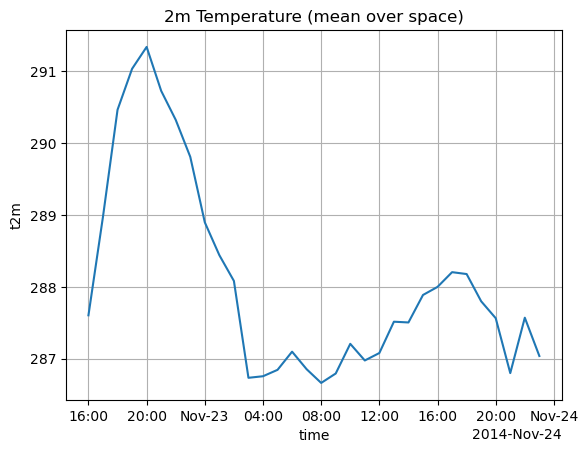

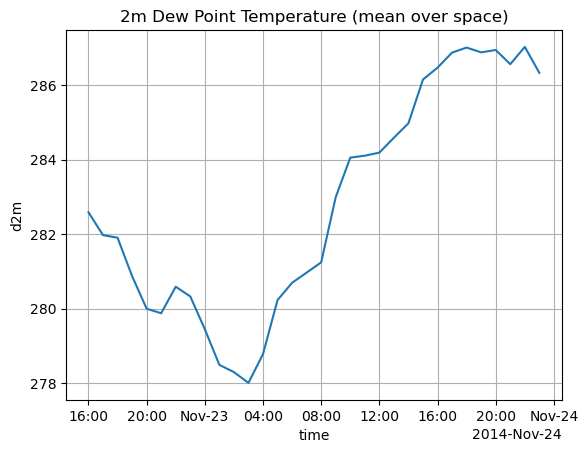

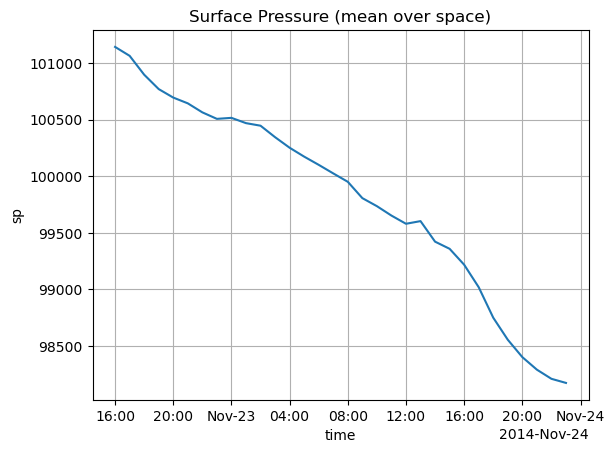

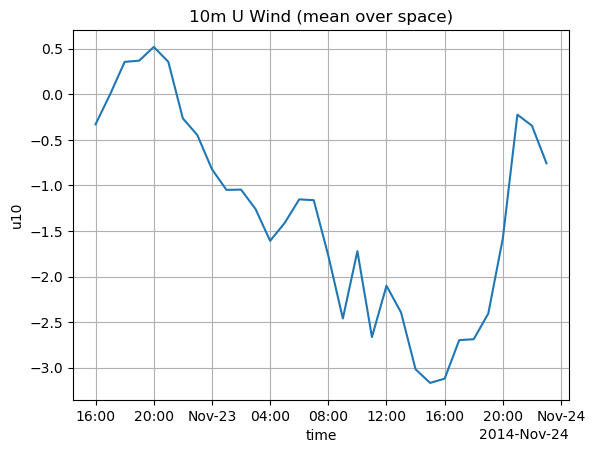

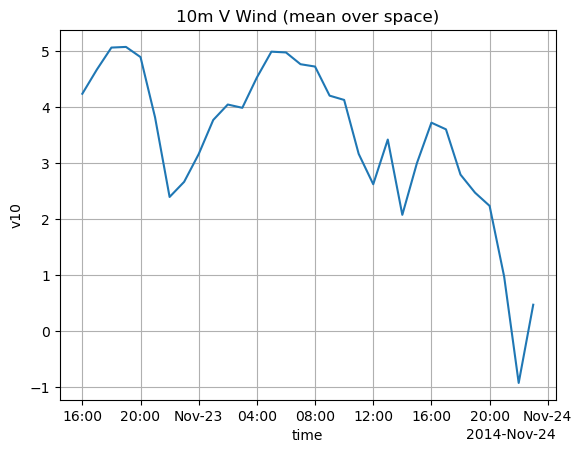

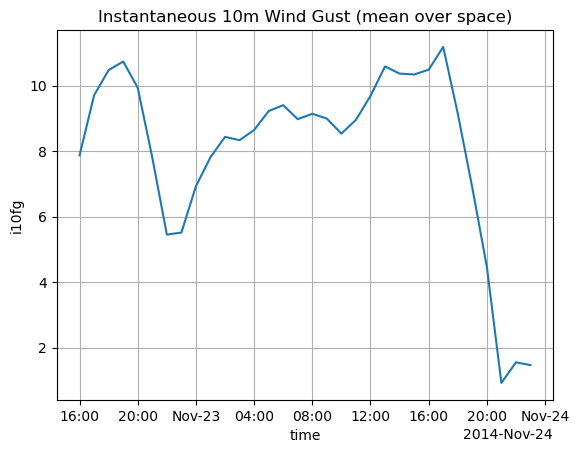

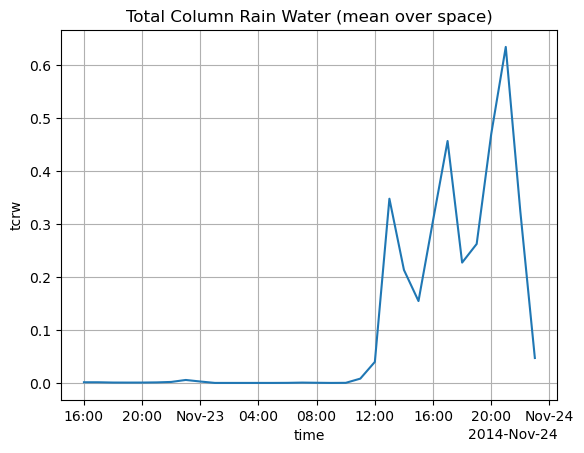

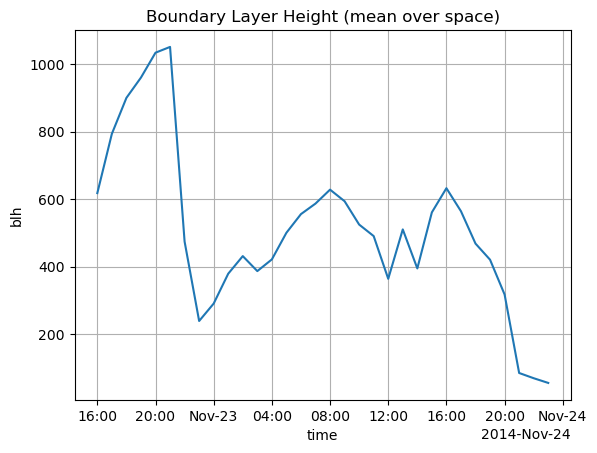

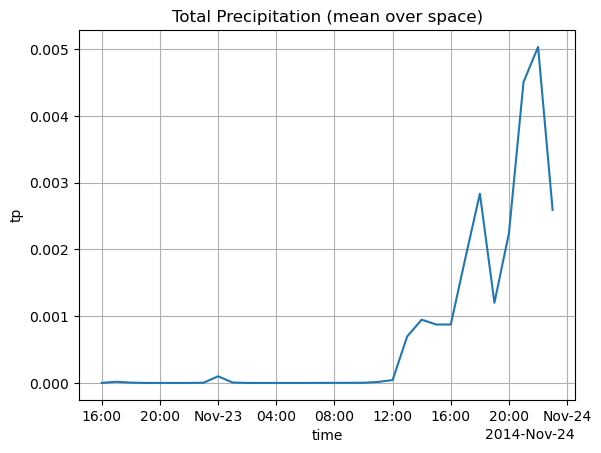

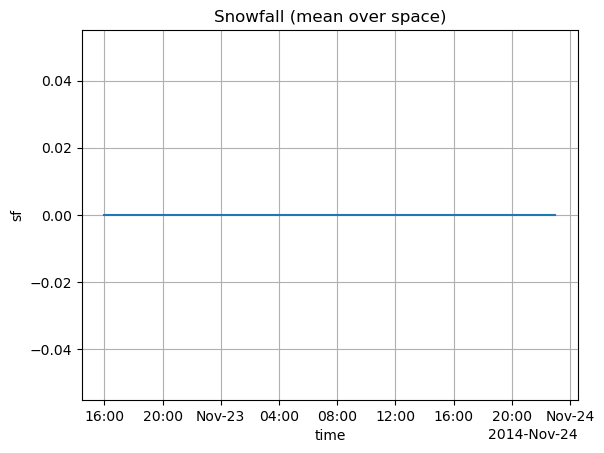

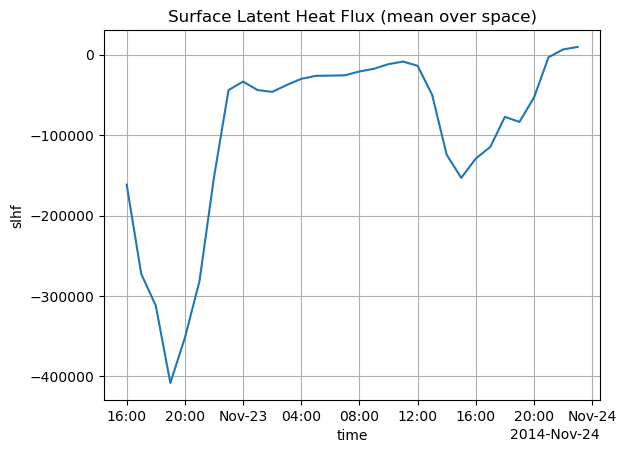

In [10]:
import matplotlib.pyplot as plt

file = "data_collection_by_hollis/WECC_weather_data/event_0_2014-11-24_15-00.nc"
#file = "data_collection_by_hollis/correlated_outage/weather_output/event_4359872023-07-3023-00.nc"
xr.open_dataset(file, engine="h5netcdf")

with open(file, "rb") as f:
    head = f.read(512)
    print(head[:300])

file_path = file
print(f"{file_path} size: {os.path.getsize(file_path)} bytes")

print(netCDF4.__version__)
print(xr.backends.list_engines())

ds = xr.open_dataset(
    file,
    engine="netcdf4"
)

print(ds)

# Dictionary of variable names and titles
plot_vars = {
    't2m': '2m Temperature',
    'd2m': '2m Dew Point Temperature',
    'sp': 'Surface Pressure',
    'u10': '10m U Wind',
    'v10': '10m V Wind',
    'i10fg': 'Instantaneous 10m Wind Gust',
    'tcrw': 'Total Column Rain Water',
    'blh': 'Boundary Layer Height',
    'tp': 'Total Precipitation',
    'sf': 'Snowfall',
    'slhf': 'Surface Latent Heat Flux',
    'avg_snswrf': 'Average Net Short-Wave Radiation Flux'
}

for var, title in plot_vars.items():
    if var in ds:
        plt.figure()
        ds[var].mean(dim=['latitude', 'longitude']).plot()
        plt.title(f"{title} (mean over space)")
        plt.grid(True)
    else:
        print(f"⚠️ Variable '{var}' not found in dataset.")
ds.close()


In [ ]:
with open(file_path, "rb") as f:
    magic = f.read(4)
    print("Magic bytes:", magic)

print(ds)
print(ds.variables)
print(ds.attrs) 

Magic bytes: b'\x89HDF'
<xarray.Dataset> Size: 1kB
Dimensions:     (valid_time: 48, latitude: 1, longitude: 1)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 384B 2014-11-22T16:00:00 ... 2014...
  * latitude    (latitude) float64 8B 36.27
  * longitude   (longitude) float64 8B -90.52
    expver      (valid_time) <U4 768B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 192B 0.0 ... 0.0
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-24T02:44 GRIB to CDM+CF via cfgrib-0.9.1...
Frozen({'tp': <xarray.Variable (valid_time: 48, latitude: 1, longitude: 1)> Size: 192B
array([[[0.000000e+00]],

       [[1.510022e-05]],

       [[0.000000e+00]],

       [[0.000000e+00]],